# Random-v2 spread analysis (hierarchical CI)

This notebook computes **dataset-level hierarchical bootstrap CIs** for the **spread** of Plan B permutation scores across the 4 random-v2 ablations:

- `pretrained_baseline`
- `pretrained_baseline5`
- `pretrained_baseline_gt`
- `pretrained_baseline5_gt`

Metrics analyzed:

- `iterations_used`
- `initial_dice`
- `final_dice`
- `dice_at_goal`

Spread definition is controlled by one string (`SPREAD_MODE`) and supports:

- `"iqr"` (default)
- `"range"`


In [2]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import sys

repo_root = Path("/data/ddmg/mvseg-ordering")
for path in [repo_root, repo_root / "UniverSeg", repo_root / "MultiverSeg", repo_root / "ScribblePrompt",]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_dataset_stat
from experiments.analysis.planb_utils import load_planb_summaries


In [ ]:
# -----------------------------
# Config (edit these)
# -----------------------------
REPO_ROOT = Path("/data/ddmg/mvseg-ordering")
PROCEDURE = "random_v2"

ABLATIONS = [
    "pretrained_baseline",
    "pretrained_baseline5",
    "pretrained_baseline_gt",
    "pretrained_baseline5_gt",
]

# Compact labels for paper legends.
ABLATION_LABELS = {
    "pretrained_baseline": "20P-Pred",
    "pretrained_baseline5": "5P-Pred",
    "pretrained_baseline_gt": "20P-GT",
    "pretrained_baseline5_gt": "5P-GT",
}

METRICS = ["iterations_used", "initial_dice", "final_dice"]

# Spread definition: "iqr" or "range"
SPREAD_MODE = "range"

# Bootstrap controls
N_BOOT = 2000
SEED = 23

# Plot controls
N_COLS = 5
ABLA_Y_STEP = 0.26  # tighter vertical spacing between ablation rows inside each panel
ABLA_Y_MARGIN = 0.10

LEGEND_ORDER = [
    "pretrained_baseline5_gt",
    "pretrained_baseline_gt",
    "pretrained_baseline5",
    "pretrained_baseline",
]

# Style scheme:
# - Same color family by commit type (Pred vs GT)
# - Marker shape + shade by prompt budget (20P vs 5P)
# Uses a colorblind-safe palette.
ABLATION_STYLES = {
    "pretrained_baseline": {"color": "#0072B2", "marker": "s"},   # Pred, 20P
    "pretrained_baseline5": {"color": "#56B4E9", "marker": "o"},  # Pred, 5P
    "pretrained_baseline_gt": {"color": "#D55E00", "marker": "s"},# GT, 20P
    "pretrained_baseline5_gt": {"color": "#E69F00", "marker": "o"},# GT, 5P
}

MARKER_SIZE = 5.5
LINE_WIDTH = 1.4
GRID_ALPHA = 0.16

SAVE_FIGURES = True
FIG_DIR = REPO_ROOT / "paper" / "figures" / "random_v2_spread_hierci"
EXPORT_FORMATS = ["pdf", "png"]



In [4]:
def make_spread_reducer(mode: str):
    mode = str(mode).strip().lower()
    if mode == "iqr":
        return lambda x: float(np.quantile(x, 0.75) - np.quantile(x, 0.25)), "IQR"
    if mode == "range":
        return lambda x: float(np.max(x) - np.min(x)), "Range"
    raise ValueError(f"Unsupported SPREAD_MODE={mode!r}. Use 'iqr' or 'range'.")


def load_ablation_planb(ablation: str) -> pd.DataFrame:
    return load_planb_summaries(
        repo_root=REPO_ROOT,
        procedure=PROCEDURE,
        ablation=ablation,
        dataset=None,
        filename="subset_support_images_summary.csv",
        allow_root_fallback=True,
    )


def compute_metric_spread_summary(
    metric: str,
    *,
    spread_mode: str,
    n_boot: int,
    seed: int,
    data_by_ablation: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    reducer, spread_label = make_spread_reducer(spread_mode)
    rows: list[dict[str, object]] = []

    for ablation in ABLATIONS:
        if ablation not in data_by_ablation:
            continue

        raw = data_by_ablation[ablation]
        if metric not in raw.columns:
            continue

        # Keep random policy only (random-v2 recipes are random policy runs).
        df = raw[raw["policy_name"].astype(str) == "random"].copy()
        if df.empty:
            continue

        for family, fam_df in df.groupby("family"):
            # Need at least one subset per task for hierarchical bootstrap.
            if fam_df["task_id"].nunique() == 0:
                continue

            stats = hierarchical_bootstrap_dataset_stat(
                fam_df,
                metric,
                policy_name="random",
                reducer=reducer,
                stat_name="subset_spread",
                n_boot=n_boot,
                seed=seed,
                task_col="task_id",
                policy_col="policy_name",
            )

            rows.append(
                {
                    "family": str(family),
                    "ablation": ablation,
                    "metric": metric,
                    "spread_mode": spread_mode,
                    "spread_label": spread_label,
                    "mean": float(stats["mean"]),
                    "ci_lo": float(stats["ci_lo"]),
                    "ci_hi": float(stats["ci_hi"]),
                    "n_tasks": int(fam_df["task_id"].nunique()),
                    "n_subsets": int(fam_df[["task_id", "subset_index"]].drop_duplicates().shape[0]),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["metric", "family", "ablation"]).reset_index(drop=True)


In [5]:
# Load all ablations once.
data_by_ablation: dict[str, pd.DataFrame] = {}
load_errors: dict[str, str] = {}

for ablation in ABLATIONS:
    try:
        df = load_ablation_planb(ablation)
        data_by_ablation[ablation] = df
        print(
            f"[loaded] {ablation}: rows={len(df):,} "
            f"tasks={df['task_id'].nunique():,} "
            f"families={df['family'].nunique():,}"
        )
    except Exception as exc:
        load_errors[ablation] = str(exc)
        print(f"[missing] {ablation}: {exc}")

if load_errors:
    print("\nAblations with load errors:")
    for k, v in load_errors.items():
        print(f"  - {k}: {v}")


[loaded] pretrained_baseline: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline5: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline_gt: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline5_gt: rows=1,630,000 tasks=163 families=10


In [6]:
# Compute one summary table per metric.
metric_to_summary: dict[str, pd.DataFrame] = {}
all_rows: list[pd.DataFrame] = []

for metric in METRICS:
    summary_df = compute_metric_spread_summary(
        metric,
        spread_mode=SPREAD_MODE,
        n_boot=N_BOOT,
        seed=SEED,
        data_by_ablation=data_by_ablation,
    )
    metric_to_summary[metric] = summary_df
    all_rows.append(summary_df)
    print(f"{metric}: rows={len(summary_df):,} families={summary_df['family'].nunique() if not summary_df.empty else 0}")

summary_all = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
summary_all.head()


iterations_used: rows=40 families=10
initial_dice: rows=40 families=10
final_dice: rows=40 families=10


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,iterations_used,range,Range,1.475540,1.323333,1.608333,6,60
1,ACDC,pretrained_baseline5,iterations_used,range,Range,0.795814,0.756667,0.838333,6,60
2,ACDC,pretrained_baseline5_gt,iterations_used,range,Range,0.647811,0.600000,0.695000,6,60
3,ACDC,pretrained_baseline_gt,iterations_used,range,Range,1.329072,1.223333,1.413375,6,60
4,BTCV,pretrained_baseline,iterations_used,range,Range,2.394066,2.168963,2.611513,20,200


In [33]:
METRIC_DISPLAY_NAMES = {
    'iterations_used': 'Interactions Used',
    'initial_dice': 'Initial Dice Score',
    'final_dice': 'Final Dice Score',
}

# Font controls
FONT_SIZE_BASE = 16
FONT_SIZE_TICKS = 16
FONT_SIZE_SUBTITLE = 18
FONT_SIZE_TITLE = 24



def plot_forest_grid_for_metric(metric: str, summary_df: pd.DataFrame) -> None:
    from matplotlib.lines import Line2D
    if summary_df.empty:
        print(f"No rows for metric={metric}")
        return

    # Sort datasets by overall spread (largest first) so the most variable datasets appear first.
    # families = (
    #     summary_df.groupby("family", as_index=False)["mean"]
    #     .mean()
    #     .sort_values("mean", ascending=False)["family"]
    #     .tolist()
    # )
    families = summary_df["family"].drop_duplicates().tolist()

    n_families = len(families)
    n_cols = int(max(1, N_COLS))
    n_rows = int(math.ceil(n_families / n_cols))

    # Use a shared x scale across panels for direct visual comparison.
    x_min = float(summary_df["ci_lo"].min())
    x_max = float(summary_df["ci_hi"].max())
    x_span = x_max - x_min
    x_pad = 0.06 * x_span if x_span > 0 else max(1e-6, abs(x_max) * 0.06)
    x_lo = x_min - x_pad
    x_hi = x_max + x_pad

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.8 * n_cols, 3.6 * n_rows),
        squeeze=False,
        sharex=True,
    )
    axes_flat = axes.ravel()

    spread_label = str(summary_df["spread_label"].iloc[0])
    metric_display = METRIC_DISPLAY_NAMES.get(metric, metric.replace("_", " ").title())
    x_label = f"{spread_label} of {metric_display}"

    for ax_idx, family in enumerate(families):
        ax = axes_flat[ax_idx]
        fam = summary_df[summary_df["family"] == family].copy()
        fam["ablation"] = pd.Categorical(fam["ablation"], categories=ABLATIONS, ordered=True)
        fam = fam.sort_values("ablation")

        # Smaller y-step reduces vertical gaps between ablation rows.
        y = np.arange(len(fam), dtype=float) * ABLA_Y_STEP

        for i, (_, row) in enumerate(fam.iterrows()):
            mean = float(row["mean"])
            ci_lo = float(row["ci_lo"])
            ci_hi = float(row["ci_hi"])
            ablation = str(row["ablation"])
            style = ABLATION_STYLES.get(ablation, {"color": "black", "marker": "o"})

            ax.errorbar(
                mean,
                y[i],
                xerr=np.array([[mean - ci_lo], [ci_hi - mean]]),
                fmt=style["marker"],
                color=style["color"],
                ecolor=style["color"],
                markerfacecolor=style["color"],
                markeredgecolor=style["color"],
                capsize=3,
                markersize=MARKER_SIZE,
                linewidth=LINE_WIDTH,
            )

        # Remove repeated y labels to declutter the grid.
        ax.set_yticks([])
        ax.tick_params(axis="y", left=False)
        ax.set_ylim(-ABLA_Y_MARGIN * ABLA_Y_STEP, (len(fam) - 1 + ABLA_Y_MARGIN) * ABLA_Y_STEP)
        ax.set_xlim(x_lo, x_hi)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.tick_params(axis="x", labelsize=FONT_SIZE_TICKS, labelbottom=True)
        ax.grid(axis="x", linestyle="--", alpha=GRID_ALPHA)

        # Keep axes visually clean for publication.
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Subtle panel label (A, B, C, ...), useful for figure captions.
        panel_label = chr(65 + ax_idx)
        ax.text(
           
            0.98,
             0.965,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=max(9, FONT_SIZE_BASE - 4),
            fontweight="semibold",
            alpha=0.85,
        )
        ax.set_title(f"{family}", fontsize=FONT_SIZE_SUBTITLE)

    for j in range(n_families, len(axes_flat)):
        axes_flat[j].axis("off")

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=ABLATION_STYLES.get(ablation, {}).get("marker", "o"),
            color=ABLATION_STYLES.get(ablation, {}).get("color", "black"),
            markerfacecolor=ABLATION_STYLES.get(ablation, {}).get("color", "black"),
            markeredgecolor=ABLATION_STYLES.get(ablation, {}).get("color", "black"),
            linestyle="None",
            markersize=8,
            label=ABLATION_LABELS.get(ablation, ablation),
        )
        for ablation in LEGEND_ORDER
    ]

    # fig.suptitle(
    #     f"{spread_label} of {metric_display} Across Random Orderings",
    #     fontsize=FONT_SIZE_TITLE,
    #     y=0.985,
    # )
    # fig.supxlabel(x_label, fontsize=FONT_SIZE_BASE + 1, y=0.04)
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        fontsize=FONT_SIZE_BASE,
        bbox_to_anchor=(0.5, 0.945),
        title_fontsize=FONT_SIZE_TITLE
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.86))

    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        stem = FIG_DIR / f"{metric}_{SPREAD_MODE}_forest_grid"
        for ext in EXPORT_FORMATS:
            out_path = stem.with_suffix(f".{ext}")
            save_kwargs = {"bbox_inches": "tight"}
            if ext.lower() == "png":
                save_kwargs["dpi"] = 220
            fig.savefig(out_path, **save_kwargs)
            print(f"saved: {out_path}")

    plt.show()

=== iterations_used ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,iterations_used,range,Range,1.475540,1.323333,1.608333,6,60
1,ACDC,pretrained_baseline5,iterations_used,range,Range,0.795814,0.756667,0.838333,6,60
2,ACDC,pretrained_baseline5_gt,iterations_used,range,Range,0.647811,0.600000,0.695000,6,60
3,ACDC,pretrained_baseline_gt,iterations_used,range,Range,1.329072,1.223333,1.413375,6,60
4,BTCV,pretrained_baseline,iterations_used,range,Range,2.394066,2.168963,2.611513,20,200
5,BTCV,pretrained_baseline5,iterations_used,range,Range,1.219070,1.184500,1.257013,20,200
6,BTCV,pretrained_baseline5_gt,iterations_used,range,Range,0.985851,0.970987,1.003000,20,200
7,BTCV,pretrained_baseline_gt,iterations_used,range,Range,1.741727,1.682000,1.793500,20,200
8,BUID,pretrained_baseline,iterations_used,range,Range,1.126360,1.019875,1.235125,4,40
9,BUID,pretrained_baseline5,iterations_used,range,Range,1.345713,1.070000,1.655000,4,40


saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/iterations_used_range_forest_grid.pdf
saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/iterations_used_range_forest_grid.png


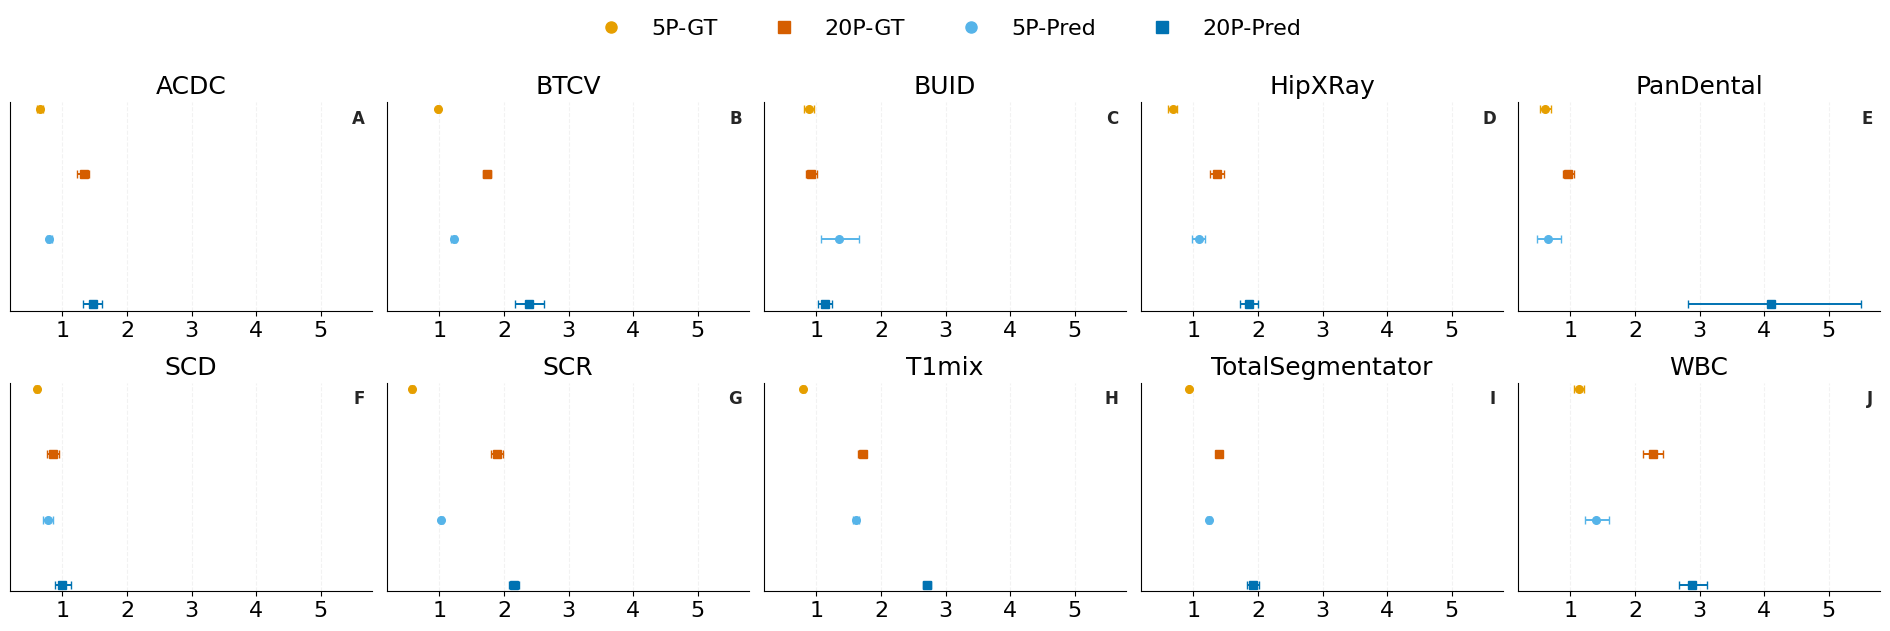

=== initial_dice ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,initial_dice,range,Range,0.152063,0.143336,0.160620,6,60
1,ACDC,pretrained_baseline5,initial_dice,range,Range,0.165105,0.157484,0.172843,6,60
2,ACDC,pretrained_baseline5_gt,initial_dice,range,Range,0.145354,0.136740,0.153842,6,60
3,ACDC,pretrained_baseline_gt,initial_dice,range,Range,0.145354,0.136740,0.153842,6,60
4,BTCV,pretrained_baseline,initial_dice,range,Range,0.181192,0.174298,0.187020,20,200
5,BTCV,pretrained_baseline5,initial_dice,range,Range,0.198618,0.191614,0.205554,20,200
6,BTCV,pretrained_baseline5_gt,initial_dice,range,Range,0.154011,0.148012,0.160268,20,200
7,BTCV,pretrained_baseline_gt,initial_dice,range,Range,0.154011,0.148012,0.160268,20,200
8,BUID,pretrained_baseline,initial_dice,range,Range,0.236286,0.216927,0.260853,4,40
9,BUID,pretrained_baseline5,initial_dice,range,Range,0.250916,0.218320,0.285972,4,40


saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/initial_dice_range_forest_grid.pdf
saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/initial_dice_range_forest_grid.png


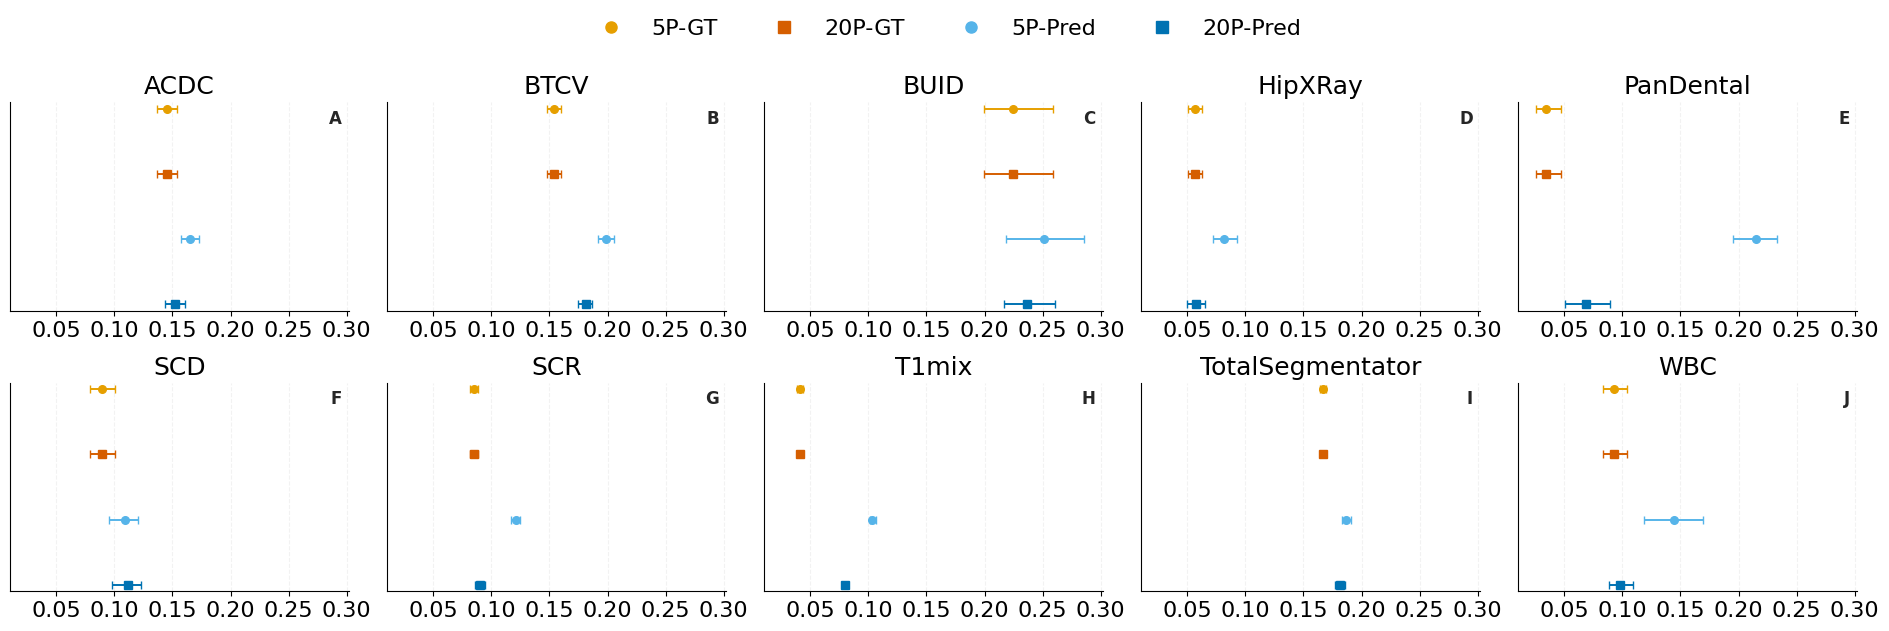

=== final_dice ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,final_dice,range,Range,0.018685,0.015993,0.021642,6,60
1,ACDC,pretrained_baseline5,final_dice,range,Range,0.050199,0.047596,0.053441,6,60
2,ACDC,pretrained_baseline5_gt,final_dice,range,Range,0.040769,0.037526,0.043847,6,60
3,ACDC,pretrained_baseline_gt,final_dice,range,Range,0.013854,0.011887,0.015947,6,60
4,BTCV,pretrained_baseline,final_dice,range,Range,0.028154,0.022571,0.034433,20,200
5,BTCV,pretrained_baseline5,final_dice,range,Range,0.099462,0.091059,0.107540,20,200
6,BTCV,pretrained_baseline5_gt,final_dice,range,Range,0.048042,0.046812,0.049325,20,200
7,BTCV,pretrained_baseline_gt,final_dice,range,Range,0.016755,0.015390,0.018378,20,200
8,BUID,pretrained_baseline,final_dice,range,Range,0.006138,0.005324,0.007120,4,40
9,BUID,pretrained_baseline5,final_dice,range,Range,0.087959,0.047080,0.136014,4,40


saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/final_dice_range_forest_grid.pdf
saved: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/final_dice_range_forest_grid.png


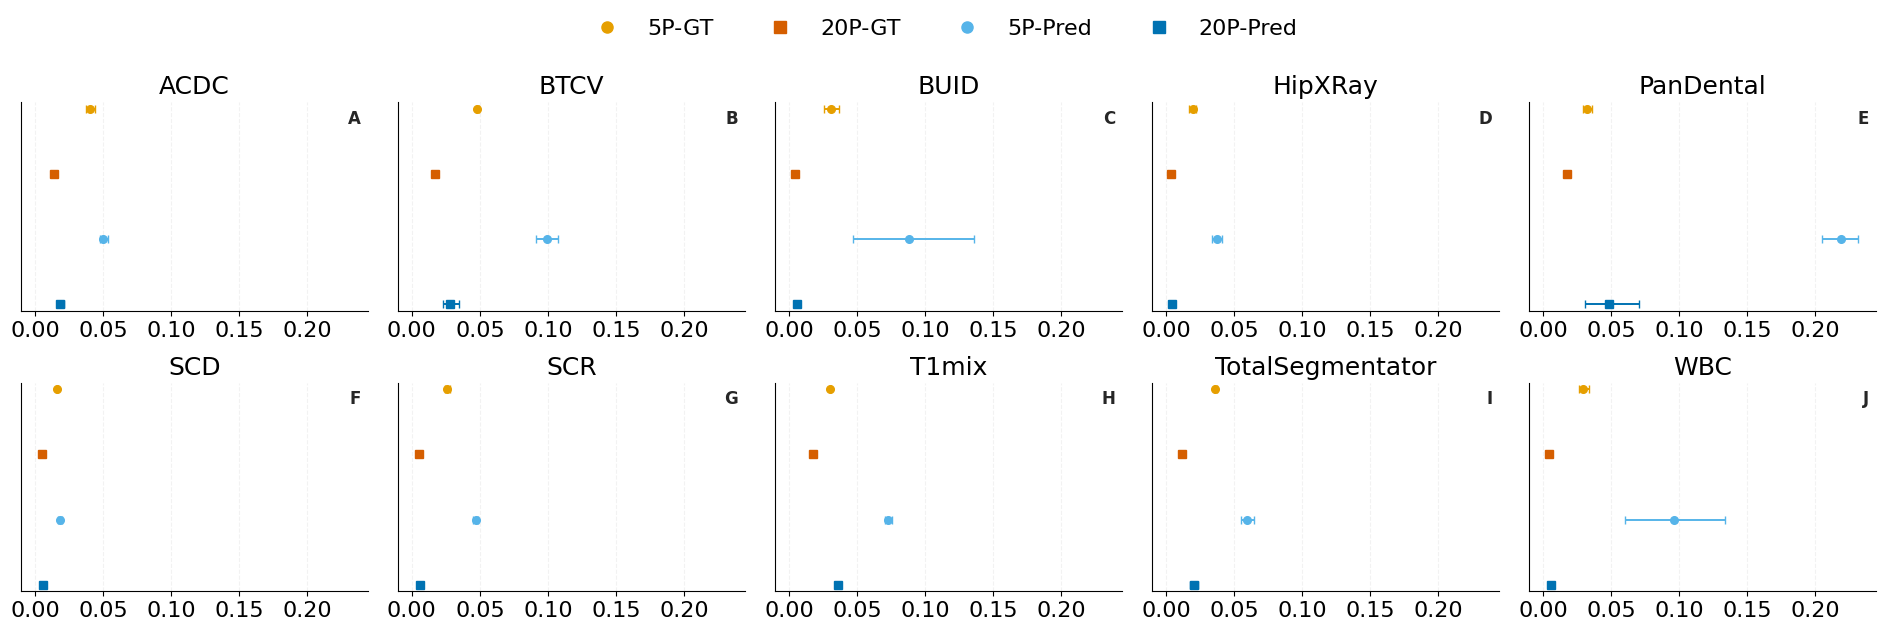

In [34]:
for metric in METRICS:
    print(f"=== {metric} ===")
    display(metric_to_summary.get(metric, pd.DataFrame()))
    plot_forest_grid_for_metric(metric, metric_to_summary.get(metric, pd.DataFrame()))


In [9]:
# Optional: save summary table for downstream analysis.
if not summary_all.empty:
    out_csv = REPO_ROOT / "paper" / "figures" / "random_v2_spread_hierci" / f"random_v2_spread_summary_{SPREAD_MODE}.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    summary_all.to_csv(out_csv, index=False)
    print(f"Wrote: {out_csv}")


Wrote: /data/ddmg/mvseg-ordering/paper/figures/random_v2_spread_hierci/random_v2_spread_summary_range.csv
